In [1]:
# Necessary Libraries
import pandas as pd
import re
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', None)

#### Load the Dataset

In [2]:
selected_columns = [
    'A_YEAR',              # Year of survey
    'B_COUNTRY_ALPHA',     # Country code
    'D_INTERVIEW',         # Interview ID (unique identifier)

    # Compassion-related Question Variables
    'Q57', 'Q58', 'Q59', 'Q60', 'Q61', 'Q62', 'Q63',
    'Q12',
    'Q108',
    'Q106',
    'Q241',
    'Q244',
    'Q253',
    'Q247',
    'Q252'
]

df_wvs = pd.read_csv('world_value_survey.csv', usecols=selected_columns)

In [3]:
# Remove leading & trailing whitespace + replace multiple spaces within names to a single underscore
df_wvs.columns = df_wvs.columns.str.strip().str.replace(r'\s+', '_', regex=True)

# Duplicate
# Automatically detect categorical/object columns
cat_cols = df_wvs.select_dtypes(include=['object', 'category']).columns
# Strip leading and trailing spaces from all categorical columns
df_wvs[cat_cols] = df_wvs[cat_cols].apply(lambda x: x.str.strip())

# Check dataset structures
print("Dataset Structures: ")
display(df_wvs.info())

# First 5 rows
print("\nFirst 5 rows: ")
display(df_wvs.head())

# Last 5 rows
print("\nLast 5 rows: ")
display(df_wvs.tail())

# Check the descriptive statistics of the datasete
print('\nCategorical Variables:')
display(df_wvs.describe(include = 'object'))

print('\nNumerical Variables: ')
display(df_wvs.describe(include = 'number'))

# Check missing values 
print("\nMissing values count for each column: ")
display(df_wvs.isnull().sum())  

print("\nMissing values percentage: ")
display(df_wvs.isna().mean() * 100)   

num_duplicates = df_wvs.duplicated().sum()
print(f"\nTotal duplicate rows: {num_duplicates}")

Dataset Structures: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97220 entries, 0 to 97219
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   A_YEAR           97220 non-null  int64 
 1   B_COUNTRY_ALPHA  97220 non-null  object
 2   D_INTERVIEW      97220 non-null  int64 
 3   Q12              97220 non-null  int64 
 4   Q57              97220 non-null  int64 
 5   Q58              97220 non-null  int64 
 6   Q59              97220 non-null  int64 
 7   Q60              97220 non-null  int64 
 8   Q61              97220 non-null  int64 
 9   Q62              97220 non-null  int64 
 10  Q63              97220 non-null  int64 
 11  Q106             97220 non-null  int64 
 12  Q108             97220 non-null  int64 
 13  Q241             97220 non-null  int64 
 14  Q244             97220 non-null  int64 
 15  Q247             97220 non-null  int64 
 16  Q252             97220 non-null  int64 
 17  Q253      

None


First 5 rows: 


,A_YEAR,B_COUNTRY_ALPHA,D_INTERVIEW,Q12,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q106,Q108,Q241,Q244,Q247,Q252,Q253
0,2018,AND,20070001,2,2,1,2,2,2,2,2,5,2,7,8,7,8,2
1,2018,AND,20070002,1,2,1,2,2,3,2,2,5,2,9,6,4,6,1
2,2018,AND,20070003,1,2,1,3,2,4,3,3,7,5,7,7,4,3,1
3,2018,AND,20070004,1,2,1,2,3,3,3,3,5,5,9,10,7,6,2
4,2018,AND,20070005,1,2,1,2,2,3,3,3,4,7,8,7,6,7,2



Last 5 rows: 


...


Missing values count for each column: 


A_YEAR             0
B_COUNTRY_ALPHA    0
D_INTERVIEW        0
Q12                0
Q57                0
Q58                0
Q59                0
Q60                0
Q61                0
Q62                0
Q63                0
Q106               0
Q108               0
Q241               0
Q244               0
Q247               0
Q252               0
Q253               0
dtype: int64


Missing values percentage: 


A_YEAR             0.0
B_COUNTRY_ALPHA    0.0
D_INTERVIEW        0.0
Q12                0.0
Q57                0.0
Q58                0.0
Q59                0.0
Q60                0.0
Q61                0.0
Q62                0.0
Q63                0.0
Q106               0.0
Q108               0.0
Q241               0.0
Q244               0.0
Q247               0.0
Q252               0.0
Q253               0.0
dtype: float64


Total duplicate rows: 0


#### Rename Some Columns

In [4]:
df_wvs.rename(columns={
    'A_YEAR': 'year_wvs',
    'B_COUNTRY_ALPHA': 'country_code',
    'D_INTERVIEW': 'id_interview'
}, inplace=True)

#### Cast Interview ID column as string

In [5]:
df_wvs['id_interview'] = df_wvs['id_interview'].astype(str)

In [6]:
df_wvs.describe(include = 'object')

,country_code,id_interview
count,97220,97220
unique,66,96221
top,CAN,858069901
freq,4018,1000


In [7]:
df_wvs = df_wvs.drop_duplicates()

#### Filter Out Negative Value Respond

In [8]:
compassion_vars = ['Q57', 'Q58', 'Q59', 'Q60', 'Q61', 'Q62', 'Q63', 
                   'Q12', 'Q108', 'Q106', 'Q241', 'Q244', 'Q253', 'Q247', 'Q252']

# Keep only rows where all values are non-negative
df_wvs_clean = df_wvs[df_wvs[compassion_vars].ge(0).all(axis=1)].copy()

In [9]:
df_wvs_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82339 entries, 0 to 97219
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year_wvs      82339 non-null  int64 
 1   country_code  82339 non-null  object
 2   id_interview  82339 non-null  object
 3   Q12           82339 non-null  int64 
 4   Q57           82339 non-null  int64 
 5   Q58           82339 non-null  int64 
 6   Q59           82339 non-null  int64 
 7   Q60           82339 non-null  int64 
 8   Q61           82339 non-null  int64 
 9   Q62           82339 non-null  int64 
 10  Q63           82339 non-null  int64 
 11  Q106          82339 non-null  int64 
 12  Q108          82339 non-null  int64 
 13  Q241          82339 non-null  int64 
 14  Q244          82339 non-null  int64 
 15  Q247          82339 non-null  int64 
 16  Q252          82339 non-null  int64 
 17  Q253          82339 non-null  int64 
dtypes: int64(16), object(2)
memory usage: 11.9+ MB


In [10]:
df_wvs_clean.describe(include = 'number')

,year_wvs,Q12,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q106,Q108,Q241,Q244,Q247,Q252,Q253
count,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000
mean,2019.109377,1.372618,1.751964,1.276904,2.186291,2.067174,2.999502,2.683807,2.785108,6.294733,5.111005,6.333815,6.818786,5.913686,5.377512,2.283049
std,1.563543,0.483505,0.431875,0.566998,0.793224,0.795594,0.810937,0.862860,0.871298,2.976079,2.996292,3.027798,2.867128,3.081503,2.728608,0.855739
min,2017.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2018.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,2.000000,4.000000,5.000000,3.000000,3.000000,2.000000
50%,2018.000000,1.000000,2.000000,1.000000,2.000000,2.000000,3.000000,3.000000,3.000000,7.000000,5.000000,7.000000,7.000000,6.000000,6.000000,2.000000
75%,2020.000000,2.000000,2.000000,1.000000,3.000000,2.000000,4.000000,3.000000,3.000000,9.000000,8.000000,9.000000,10.000000,9.000000,7.000000,3.000000
max,2023.000000,2.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


#### Reverse Scaling

In [11]:
vars_to_reverse = ['Q57', 'Q58', 'Q59', 'Q60', 'Q61', 'Q62', 'Q63',
                   'Q12', 'Q108', 'Q106', 'Q253']

for var in vars_to_reverse:
    min_val = df_wvs_clean[var].min()
    max_val = df_wvs_clean[var].max()
    df_wvs_clean[var] = max_val + min_val - df_wvs_clean[var]

In [12]:
df_wvs_clean.describe(include = 'number')

,year_wvs,Q12,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q106,Q108,Q241,Q244,Q247,Q252,Q253
count,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000
mean,2019.109377,1.627382,1.248036,3.723096,2.813709,2.932826,2.000498,2.316193,2.214892,4.705267,5.888995,6.333815,6.818786,5.913686,5.377512,2.716951
std,1.563543,0.483505,0.431875,0.566998,0.793224,0.795594,0.810937,0.862860,0.871298,2.976079,2.996292,3.027798,2.867128,3.081503,2.728608,0.855739
min,2017.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2018.000000,1.000000,1.000000,4.000000,2.000000,3.000000,1.000000,2.000000,2.000000,2.000000,3.000000,4.000000,5.000000,3.000000,3.000000,2.000000
50%,2018.000000,2.000000,1.000000,4.000000,3.000000,3.000000,2.000000,2.000000,2.000000,4.000000,6.000000,7.000000,7.000000,6.000000,6.000000,3.000000
75%,2020.000000,2.000000,1.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,7.000000,9.000000,9.000000,10.000000,9.000000,7.000000,3.000000
max,2023.000000,2.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


#### Mean Max Scale All Variables

In [13]:
scaler = MinMaxScaler()
df_scaled = df_wvs_clean.copy()
df_scaled[compassion_vars] = scaler.fit_transform(df_wvs_clean[compassion_vars])

In [14]:
df_scaled.describe(include = 'number')

,year_wvs,Q12,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q106,Q108,Q241,Q244,Q247,Q252,Q253
count,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000,82339.000000
mean,2019.109377,0.627382,0.248036,0.907699,0.604570,0.644275,0.333499,0.438731,0.404964,0.411696,0.543222,0.633382,0.681879,0.591369,0.486390,0.572317
std,1.563543,0.483505,0.431875,0.188999,0.264408,0.265198,0.270312,0.287620,0.290433,0.330675,0.332921,0.302780,0.286713,0.308150,0.303179,0.285246
min,2017.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,0.000000,0.000000,1.000000,0.333333,0.666667,0.000000,0.333333,0.333333,0.111111,0.222222,0.400000,0.500000,0.300000,0.222222,0.333333
50%,2018.000000,1.000000,0.000000,1.000000,0.666667,0.666667,0.333333,0.333333,0.333333,0.333333,0.555556,0.700000,0.700000,0.600000,0.555556,0.666667
75%,2020.000000,1.000000,0.000000,1.000000,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.888889,0.900000,1.000000,0.900000,0.666667,0.666667
max,2023.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Factor Analysis

In [15]:
X = df_scaled[compassion_vars]

In [16]:
fa = FactorAnalyzer(n_factors=1, rotation=None)
fa.fit(X)

C:\Users\LENOVO\anaconda3\envs\Assignment2\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=1, rotation=None, rotation_kwargs={})

In [17]:
loadings = pd.DataFrame(fa.loadings_, index=compassion_vars, columns=['Compassion_Factor_Loading'])
print(loadings.sort_values(by='Compassion_Factor_Loading', ascending=False))

      Compassion_Factor_Loading
Q247                   0.037253
Q108                   0.020289
Q106                  -0.037673
Q241                  -0.041034
Q12                   -0.069660
Q244                  -0.079285
Q252                  -0.167522
Q253                  -0.231402
Q58                   -0.237677
Q57                   -0.425036
Q59                   -0.541410
Q60                   -0.608336
Q61                   -0.686391
Q62                   -0.691920
Q63                   -0.719045


In [18]:
df_scaled['compassion_score'] = fa.transform(X)[:, 0]

C:\Users\LENOVO\anaconda3\envs\Assignment2\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [19]:
df_country_score = df_scaled.groupby('country_code')['compassion_score'].mean().reset_index()

print(df_country_score.head())

  country_code  compassion_score
0          AND         -0.315835
1          ARG         -0.358173
2          ARM          0.274825
3          AUS         -0.732132
4          BGD          0.104018


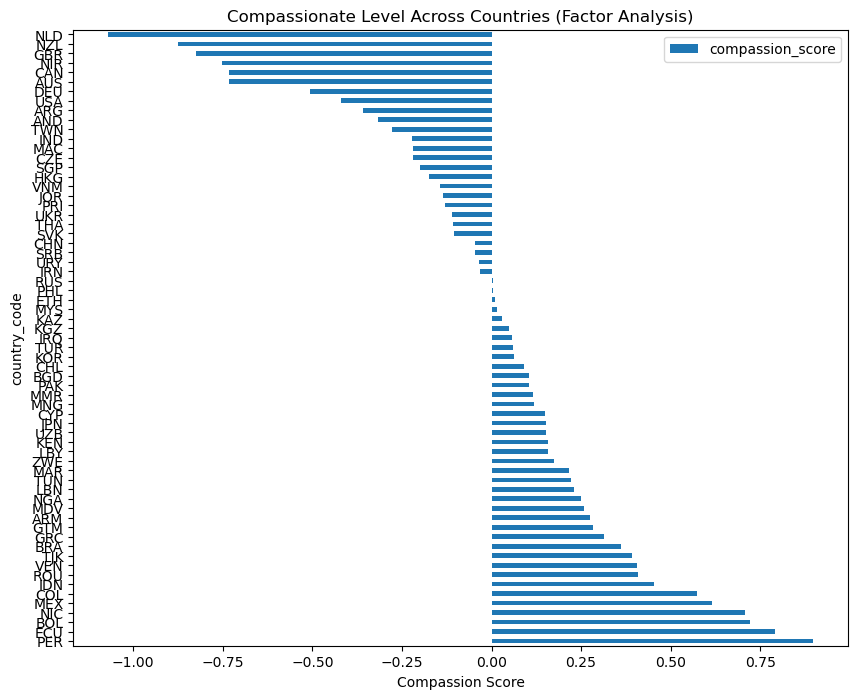

In [20]:
import matplotlib.pyplot as plt

df_country_score.sort_values('compassion_score', ascending=False).plot(
    x='country_code', y='compassion_score', kind='barh', figsize=(10, 8))

plt.xlabel('Compassion Score')
plt.title('Compassionate Level Across Countries (Factor Analysis)')
plt.show()

In [21]:
df_country_score_sorted = df_country_score.sort_values(by='compassion_score', ascending=False).reset_index(drop=True)

In [22]:
df_country_score_sorted.head(5)

,country_code,compassion_score
0,PER,0.897303
1,ECU,0.791035
2,BOL,0.720819
3,NIC,0.707872
4,MEX,0.616769


In [23]:
df_country_score_sorted.tail(5)

,country_code,compassion_score
60,CAN,-0.732712
61,NIR,-0.752225
62,GBR,-0.824722
63,NZL,-0.874972
64,NLD,-1.069527


In [24]:
# Flip the compassion score
df_country_score['compassion_score'] = -df_country_score['compassion_score']

#### Merge

In [25]:
df_prev = pd.read_csv('processed_fourth.csv')

In [26]:
df_merged = pd.merge(
    df_prev,
    df_country_score,
    on='country_code',  # Common column for joining
    how='inner'         # Inner Join: keep only matching rows
)

In [27]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      55 non-null     object 
 1   country_code                 55 non-null     object 
 2   gini                         55 non-null     float64
 3   gdp_per_capita               55 non-null     float64
 4   happiness_score              55 non-null     float64
 5   percent_gdp_social_spending  14 non-null     float64
 6   compassion_score             55 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.1+ KB


In [28]:
df_merged.to_csv('data_exploration_data.csv', index=False)

In [29]:
# Get unique values from both datasets
set1 = set(df_country_score['country_code'].unique())
set2 = set(df_prev['country_code'].unique())

# Values in df1 but not in df2
diff_1_not_in_2 = set1 - set2

# Values in df2 but not in df1
diff_2_not_in_1 = set2 - set1

print("Country in df_country_score but not in df_prev: \n", diff_1_not_in_2)
print("\nCountry in df_prev but not in df_country_score: \n", diff_2_not_in_1)

Country in df_country_score but not in df_prev: 
 {'TWN', 'AND', 'MAC', 'SGP', 'VEN', 'LBY', 'NIR', 'NZL', 'PRI', 'HKG', 'MDV'}

Country in df_prev but not in df_country_score: 
 {'MUS', 'MLT', 'ZAF', 'POL', 'BEN', 'AZE', 'MDA', 'NAM', 'SVN', 'NPL', 'SWE', 'LBR', 'ISL', 'PRT', 'SWZ', 'ITA', 'NER', 'TCD', 'NOR', 'LKA', 'BFA', 'COM', 'PAN', 'MRT', 'DOM', 'CRI', 'LTU', 'GAB', 'TZA', 'BEL', 'ALB', 'RWA', 'EST', 'COG', 'TGO', 'ZMB', 'FIN', 'BGR', 'EGY', 'PSE', 'LAO', 'YEM', 'LVA', 'GHA', 'MDG', 'ISR', 'DNK', 'TKM', 'BLR', 'MNE', 'HRV', 'MWI', 'GEO', 'FRA', 'MLI', 'LSO', 'SLE', 'SEN', 'MKD', 'ESP', 'CHE', 'HUN', 'BIH', 'PRY', 'UGA', 'CIV', 'LUX', 'JAM', 'IRL', 'HND', 'GMB', 'AUT', 'DZA', 'GIN', 'SLV', 'ARE', 'MOZ', 'BWA', 'CMR'}
